# 03 · Complejos simpliciales y persistencia homológica

Analizamos la **cobertura geográfica de la salud pública en CDMX** comparando dos niveles de atención:

- **Primer nivel** (511 ubicaciones): consultorios médicos, dentales, de otros profesionales y centros ambulatorios. Atención cercana, preventiva, del día a día.
- **Segundo / tercer nivel** (148 ubicaciones): hospitales y laboratorios. Hospitalización, urgencias, especialidad, diagnóstico.

**Pregunta central:** ¿los huecos de cobertura (zonas pobladas rodeadas de servicios pero sin servicios adentro) del primer nivel coinciden con los del segundo/tercer nivel, o son zonas distintas de la ciudad?

**Herramienta:** Alpha complex (Gudhi) + homología persistente. El Alpha complex vive dentro de la triangulación de Delaunay, así que es muy eficiente en 2D y da la misma homología persistente que el complejo de Čech.

**Nota metodológica importante:** la nube de segundo/tercer nivel tiene solo 148 puntos. Es suficiente para correr el análisis, pero los huecos poco persistentes pueden ser azar. Aplicamos un umbral de persistencia y reportamos solo los huecos claramente destacados; esto se discute como limitación.

In [3]:
%pip install gudhi

Note: you may need to restart the kernel to use updated packages.


In [4]:
# pip install gudhi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gudhi
import os

print(f"Gudhi versión: {gudhi.__version__}")

Gudhi versión: 3.12.0


## Cargar datos y separar por nivel de atención

Usamos el sector **público** (`salud_cdmx_publico.csv`, salida del notebook 02) y lo partimos en las dos nubes según la columna `nivel_atencion`.

In [5]:
PROC_DIR = "../data/processed"
df_pub = pd.read_csv(os.path.join(PROC_DIR, "salud_cdmx_publico.csv"))

# Separar en las dos nubes
nube_primer  = df_pub[df_pub["nivel_atencion"] == "primer_nivel"].copy()
nube_segundo = df_pub[df_pub["nivel_atencion"] == "segundo_tercer_nivel"].copy()

print(f"Primer nivel:          {len(nube_primer):,} ubicaciones")
print(f"Segundo/tercer nivel:  {len(nube_segundo):,} ubicaciones")

# Coordenadas métricas (UTM 14N) como arrays Nx2
pts_primer  = nube_primer[["x_m", "y_m"]].to_numpy()
pts_segundo = nube_segundo[["x_m", "y_m"]].to_numpy()

Primer nivel:          511 ubicaciones
Segundo/tercer nivel:  148 ubicaciones


## Construcción del Alpha complex y persistencia

El **Alpha complex** filtra la triangulación de Delaunay de la nube de puntos. A medida que crece el parámetro de filtración, se van añadiendo aristas y triángulos.

- **H₀** (dimensión 0): componentes conexas. Una barra H₀ larga = un grupo de servicios aislado del resto.
- **H₁** (dimensión 1): agujeros / ciclos. Un H₁ persistente = una región rodeada de servicios pero **sin servicios adentro** → un hueco de cobertura.

En Gudhi el valor de filtración del Alpha complex es el **cuadrado del circunradio**. Para interpretarlo como distancia tomamos la raíz cuadrada: así los valores de nacimiento y muerte quedan en **metros**, y un agujero que muere en `r` metros corresponde a una zona vacía de ese orden de tamaño.

In [6]:
def construir_y_persistir(puntos):
    """Construye el Alpha complex y devuelve (alpha, simplex_tree, diagrama).

    El diagrama se devuelve con filtraciones convertidas a metros (raíz del
    cuadrado del circunradio).
    """
    alpha = gudhi.AlphaComplex(points=puntos)
    st = alpha.create_simplex_tree()
    diag = st.persistence()
    return alpha, st, diag


def separar_dimensiones(diag):
    """Separa el diagrama en H0 y H1, con filtraciones convertidas a metros."""
    h0, h1 = [], []
    for dim, (birth, death) in diag:
        b = np.sqrt(birth) if birth > 0 else 0.0
        d = np.sqrt(death) if death != float("inf") else float("inf")
        if dim == 0:
            h0.append((b, d))
        elif dim == 1:
            h1.append((b, d))
    return h0, h1


# Construir para las dos nubes
alpha_p, st_p, diag_p = construir_y_persistir(pts_primer)
alpha_s, st_s, diag_s = construir_y_persistir(pts_segundo)

h0_p, h1_p = separar_dimensiones(diag_p)
h0_s, h1_s = separar_dimensiones(diag_s)

print("PRIMER NIVEL")
print(f"  Símplices en el complejo: {st_p.num_simplices():,}")
print(f"  Componentes H0: {len(h0_p)}  |  Agujeros H1: {len(h1_p)}")
print("\nSEGUNDO / TERCER NIVEL")
print(f"  Símplices en el complejo: {st_s.num_simplices():,}")
print(f"  Componentes H0: {len(h0_s)}  |  Agujeros H1: {len(h1_s)}")

PRIMER NIVEL
  Símplices en el complejo: 3,039
  Componentes H0: 511  |  Agujeros H1: 394

SEGUNDO / TERCER NIVEL
  Símplices en el complejo: 867
  Componentes H0: 148  |  Agujeros H1: 94


## Diagramas de persistencia

Cada punto es una característica topológica. La distancia a la diagonal = persistencia: cuanto más arriba, más robusta la característica. Los puntos pegados a la diagonal son ruido.

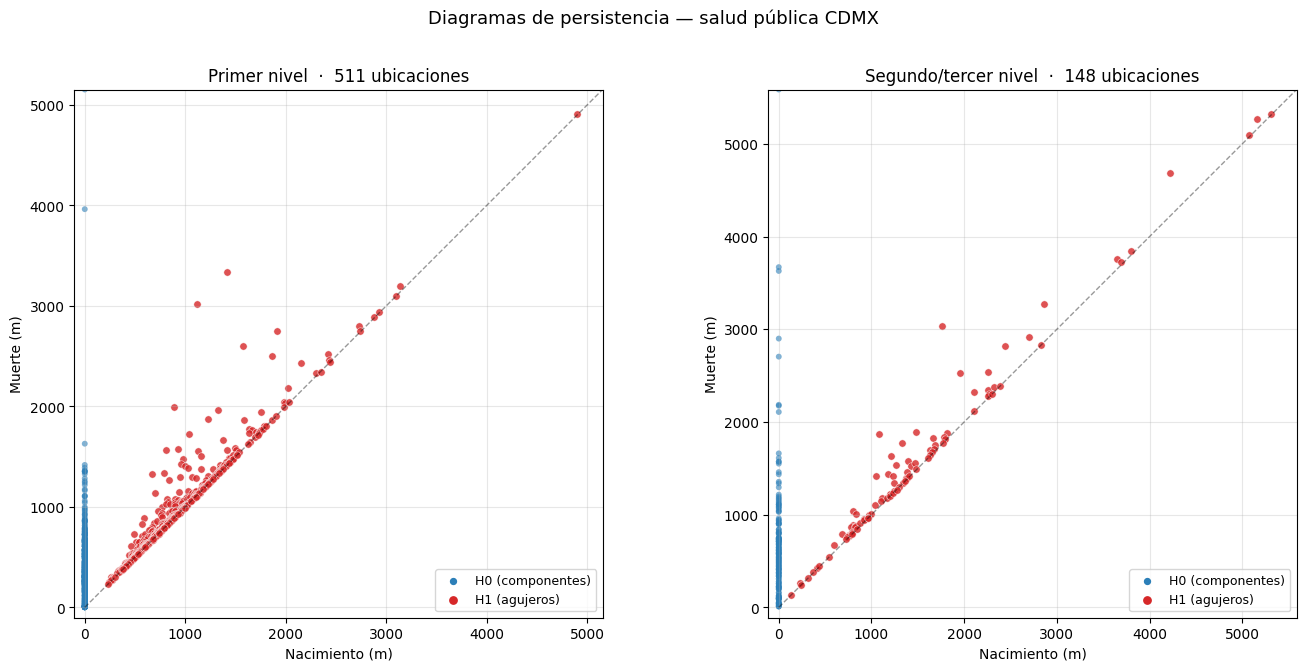

In [7]:
def plot_diagrama(ax, h0, h1, titulo):
    """Diagrama de persistencia en metros."""
    # Limite para dibujar la diagonal y los puntos esenciales
    finitos = [d for _, d in h0 + h1 if d != float("inf")]
    vmax = max(finitos) * 1.05 if finitos else 1.0

    ax.plot([0, vmax], [0, vmax], "k--", alpha=0.4, lw=1)

    # H0 (componentes que mueren; la esencial se dibuja arriba)
    for b, d in h0:
        d_plot = vmax if d == float("inf") else d
        ax.scatter(b, d_plot, c="#2c7fb8", s=18, alpha=0.6, edgecolors="none")
    # H1
    for b, d in h1:
        ax.scatter(b, d, c="#d62728", s=28, alpha=0.8, edgecolors="white", linewidth=0.4)

    ax.set_xlabel("Nacimiento (m)")
    ax.set_ylabel("Muerte (m)")
    ax.set_title(titulo)
    ax.set_xlim(-vmax*0.02, vmax)
    ax.set_ylim(-vmax*0.02, vmax)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    # Leyenda manual
    ax.scatter([], [], c="#2c7fb8", s=18, label="H0 (componentes)")
    ax.scatter([], [], c="#d62728", s=28, label="H1 (agujeros)")
    ax.legend(loc="lower right", fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
plot_diagrama(axes[0], h0_p, h1_p, f"Primer nivel  ·  {len(pts_primer)} ubicaciones")
plot_diagrama(axes[1], h0_s, h1_s, f"Segundo/tercer nivel  ·  {len(pts_segundo)} ubicaciones")
plt.suptitle("Diagramas de persistencia — salud pública CDMX", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Diagramas de barras (barcodes)

Cada barra es una característica; su longitud es la persistencia. Mostramos solo H₁ (los agujeros), ordenados de más a menos persistente.

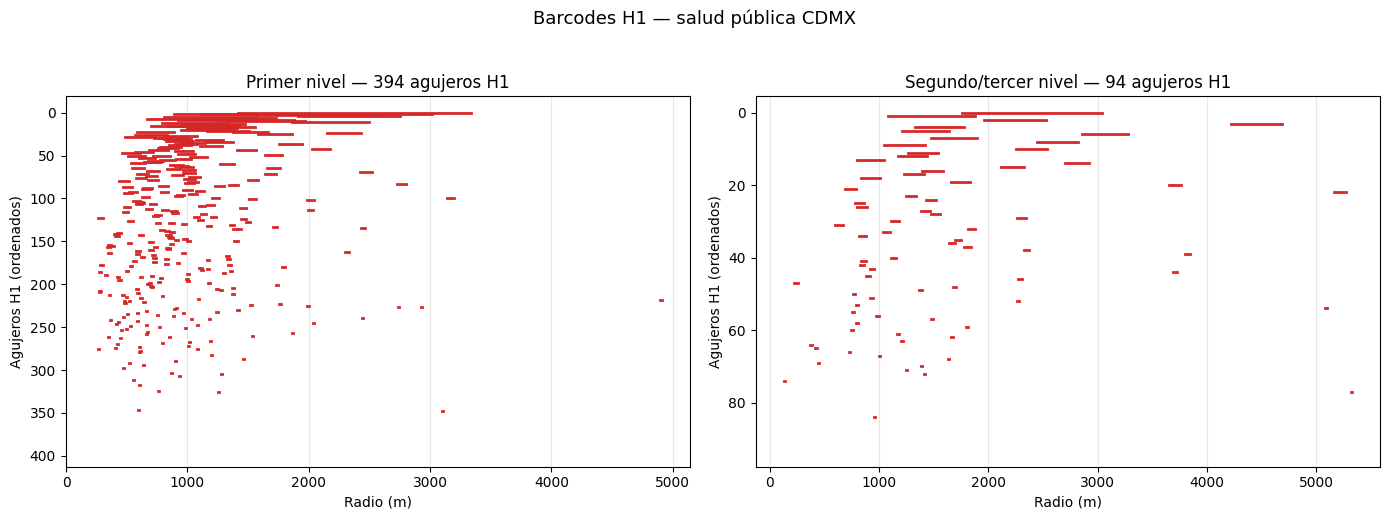

In [8]:
def plot_barcode_h1(ax, h1, titulo, color="#d62728"):
    """Barcode de H1 ordenado por persistencia."""
    h1_fin = [(b, d) for b, d in h1 if d != float("inf")]
    h1_fin.sort(key=lambda x: -(x[1] - x[0]))
    for i, (b, d) in enumerate(h1_fin):
        ax.plot([b, d], [i, i], color=color, lw=2)
    ax.set_xlabel("Radio (m)")
    ax.set_ylabel("Agujeros H1 (ordenados)")
    ax.set_title(titulo)
    ax.grid(alpha=0.3, axis="x")
    ax.invert_yaxis()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_barcode_h1(axes[0], h1_p, f"Primer nivel — {len(h1_p)} agujeros H1")
plot_barcode_h1(axes[1], h1_s, f"Segundo/tercer nivel — {len(h1_s)} agujeros H1")
plt.suptitle("Barcodes H1 — salud pública CDMX", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## Identificar y localizar los huecos persistentes

Detectar un agujero no basta: hay que saber **dónde está** en la ciudad. Cuando un agujero H₁ muere, lo hace porque un triángulo lo rellena. El **circuncentro de ese triángulo** es el punto más alejado de los servicios que rodean el hueco — es decir, el centro de la zona desatendida.

Extraemos ese centro para cada agujero usando `persistence_pairs()` de Gudhi, que vincula cada característica con el símplex que la crea y el que la destruye.

In [9]:
def circuncentro(p1, p2, p3):
    """Circuncentro de un triángulo en 2D. Si es degenerado, devuelve el centroide."""
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return (ax+bx+cx)/3, (ay+by+cy)/3
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy


def extraer_huecos(alpha, st):
    """Devuelve un DataFrame con un renglón por agujero H1:
    centro (cx, cy en UTM), radios de nacimiento/muerte y persistencia, todo en metros."""
    filas = []
    for s_birth, s_death in st.persistence_pairs():
        # H1: nace una arista (2 vértices), muere un triángulo (3 vértices)
        if len(s_birth) == 2 and len(s_death) == 3:
            r_nac = np.sqrt(st.filtration(s_birth))
            r_mue = np.sqrt(st.filtration(s_death))
            tri = [alpha.get_point(i) for i in s_death]
            cx, cy = circuncentro(tri[0], tri[1], tri[2])
            filas.append({
                "cx": cx, "cy": cy,
                "r_nacimiento": r_nac, "r_muerte": r_mue,
                "persistencia": r_mue - r_nac,
            })
    huecos = pd.DataFrame(filas).sort_values("persistencia", ascending=False)
    return huecos.reset_index(drop=True)


huecos_p = extraer_huecos(alpha_p, st_p)
huecos_s = extraer_huecos(alpha_s, st_s)

print(f"Agujeros H1 — primer nivel: {len(huecos_p)}")
print(f"Agujeros H1 — segundo/tercer nivel: {len(huecos_s)}")
print("\nTop 10 huecos primer nivel (radio en metros):")
print(huecos_p.head(10).round(1).to_string(index=False))

Agujeros H1 — primer nivel: 394
Agujeros H1 — segundo/tercer nivel: 94

Top 10 huecos primer nivel (radio en metros):
      cx        cy  r_nacimiento  r_muerte  persistencia
497251.5 2126187.1        1420.5    3335.1        1914.6
479223.9 2135349.0        1118.2    3019.0        1900.9
486473.1 2140591.4         888.5    1993.4        1105.0
491467.8 2131160.1        1575.6    2598.2        1022.6
500620.9 2135293.1        1909.7    2752.0         842.3
491876.6 2140085.4         806.7    1563.3         756.6
492580.0 2149886.8        1033.0    1727.0         694.0
486488.3 2153119.1         665.6    1329.7         664.1
486219.9 2144038.8         923.3    1576.2         652.9
486829.9 2134999.8        1224.0    1877.0         652.9


## Separar señal de ruido

No todos los agujeros importan. Definimos un **umbral de persistencia**: solo nos quedamos con huecos cuya persistencia destaca claramente. Usamos un criterio basado en la distribución (percentil alto), y para el segundo/tercer nivel somos más estrictos por la menor masa de datos.

In [10]:
def huecos_significativos(huecos, percentil=90):
    """Filtra los huecos cuya persistencia supera el percentil dado."""
    if len(huecos) == 0:
        return huecos
    umbral = np.percentile(huecos["persistencia"], percentil)
    return huecos[huecos["persistencia"] >= umbral].copy()

# Primer nivel: percentil 90. Segundo/tercer: percentil 90 también, pero
# con menos puntos conviene revisar visualmente el barcode antes de concluir.
sig_p = huecos_significativos(huecos_p, percentil=90)
sig_s = huecos_significativos(huecos_s, percentil=90)

print(f"Huecos significativos — primer nivel: {len(sig_p)} de {len(huecos_p)}")
print(f"  Persistencia mínima retenida: {sig_p['persistencia'].min():.0f} m")
print(f"\nHuecos significativos — segundo/tercer nivel: {len(sig_s)} de {len(huecos_s)}")
if len(sig_s) > 0:
    print(f"  Persistencia mínima retenida: {sig_s['persistencia'].min():.0f} m")

Huecos significativos — primer nivel: 40 de 394
  Persistencia mínima retenida: 180 m

Huecos significativos — segundo/tercer nivel: 10 de 94
  Persistencia mínima retenida: 371 m


## Mapeo geográfico de los huecos

Dibujamos cada nube de servicios con sus huecos significativos superpuestos. El círculo marca el centro y el radio de muerte (tamaño aproximado de la zona desatendida).

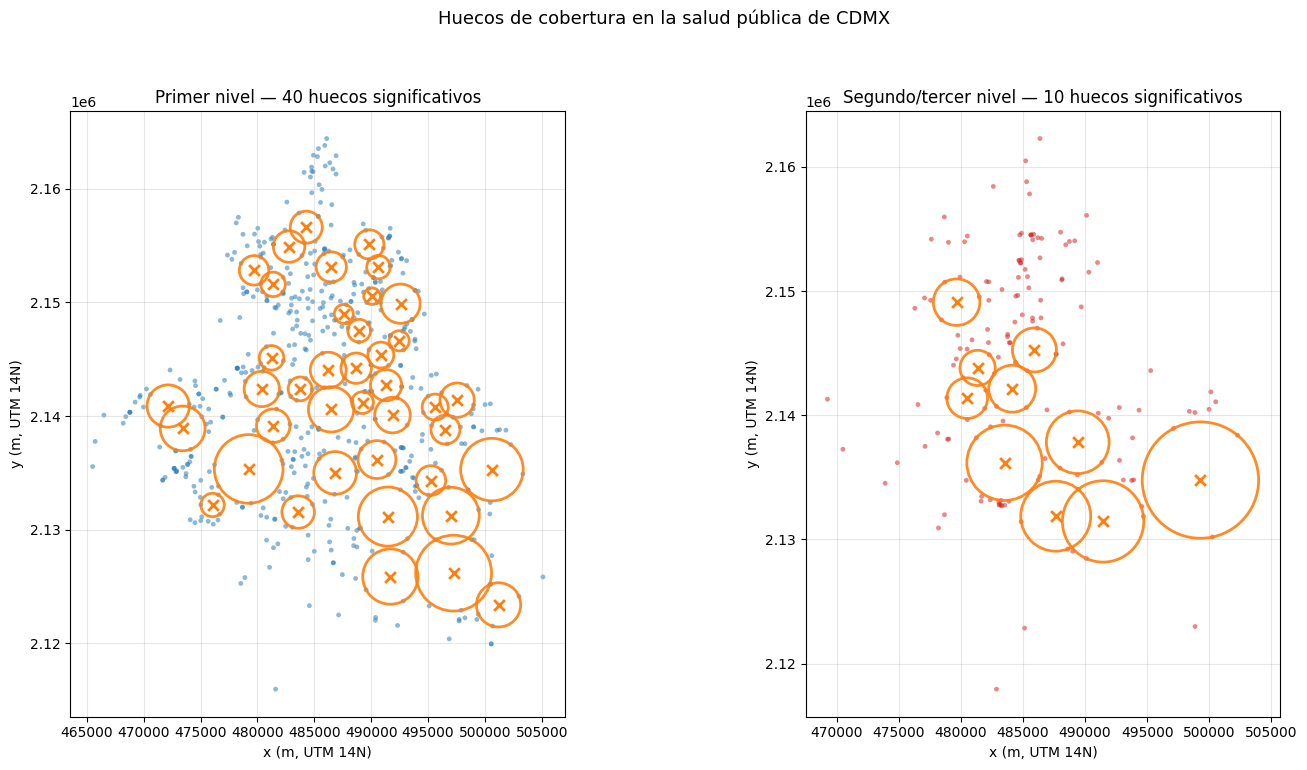

In [11]:
def plot_nube_con_huecos(ax, pts, huecos_sig, titulo, color_pts):
    """Scatter de servicios + círculos en los huecos significativos."""
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.55,
               color=color_pts, edgecolors="none", label="Servicios")
    for _, h in huecos_sig.iterrows():
        circ = plt.Circle((h["cx"], h["cy"]), h["r_muerte"],
                          fill=False, color="#ff7f0e", lw=2, alpha=0.9)
        ax.add_patch(circ)
        ax.scatter(h["cx"], h["cy"], marker="x", s=60,
                   color="#ff7f0e", linewidth=2)
    ax.set_xlabel("x (m, UTM 14N)")
    ax.set_ylabel("y (m, UTM 14N)")
    ax.set_title(titulo)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
plot_nube_con_huecos(axes[0], pts_primer, sig_p,
                     f"Primer nivel — {len(sig_p)} huecos significativos", "#2c7fb8")
plot_nube_con_huecos(axes[1], pts_segundo, sig_s,
                     f"Segundo/tercer nivel — {len(sig_s)} huecos significativos", "#d62728")
plt.suptitle("Huecos de cobertura en la salud pública de CDMX", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Comparación entre niveles

¿Los huecos del primer nivel coinciden con los del segundo/tercer nivel? Dos miradas:

1. **Visual:** los dos conjuntos de huecos sobre el mismo plano.
2. **Cuantitativa:** la distancia *bottleneck* entre los diagramas de persistencia H₁ — una medida global de qué tan distintas son las dos topologías.

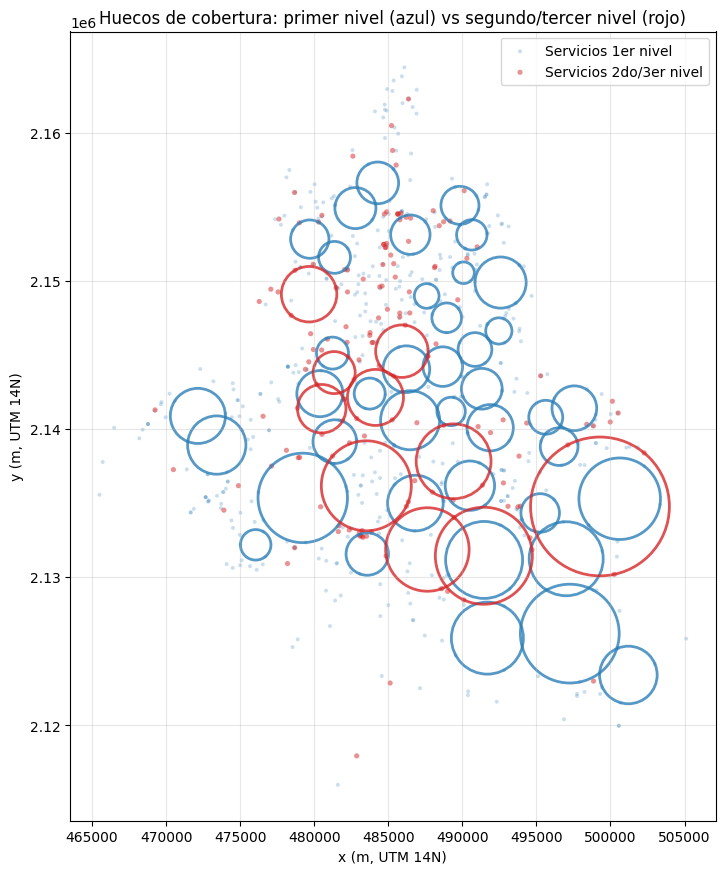

In [12]:
# 1) Vista combinada
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(pts_primer[:, 0], pts_primer[:, 1], s=8, alpha=0.25,
           color="#2c7fb8", edgecolors="none", label="Servicios 1er nivel")
ax.scatter(pts_segundo[:, 0], pts_segundo[:, 1], s=14, alpha=0.5,
           color="#d62728", edgecolors="none", label="Servicios 2do/3er nivel")

for _, h in sig_p.iterrows():
    ax.add_patch(plt.Circle((h["cx"], h["cy"]), h["r_muerte"],
                 fill=False, color="#2c7fb8", lw=2, alpha=0.8))
for _, h in sig_s.iterrows():
    ax.add_patch(plt.Circle((h["cx"], h["cy"]), h["r_muerte"],
                 fill=False, color="#d62728", lw=2, alpha=0.8))

ax.set_xlabel("x (m, UTM 14N)")
ax.set_ylabel("y (m, UTM 14N)")
ax.set_title("Huecos de cobertura: primer nivel (azul) vs segundo/tercer nivel (rojo)")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# 2) Distancia bottleneck entre los diagramas H1 (en metros)
h1_p_arr = np.array([[b, d] for b, d in h1_p if d != float("inf")])
h1_s_arr = np.array([[b, d] for b, d in h1_s if d != float("inf")])

bottleneck = gudhi.bottleneck_distance(h1_p_arr, h1_s_arr)
print(f"Distancia bottleneck entre H1(primer nivel) y H1(segundo/tercer nivel): {bottleneck:.1f} m")
print()
print("Interpretación: es la mayor discrepancia que existe al emparejar de forma")
print("óptima los agujeros de un nivel con los del otro. Un valor grande indica que")
print("la estructura de huecos de los dos niveles es claramente distinta.")

Distancia bottleneck entre H1(primer nivel) y H1(segundo/tercer nivel): 809.1 m

Interpretación: es la mayor discrepancia que existe al emparejar de forma
óptima los agujeros de un nivel con los del otro. Un valor grande indica que
la estructura de huecos de los dos niveles es claramente distinta.


## Conclusiones preliminares

Puntos a desarrollar en el reporte una vez observados los resultados de arriba:

- **Cuántos huecos significativos** tiene cada nivel y de qué tamaño (radio de muerte en metros → traducible a minutos caminando: ~80 m/min).
- **¿Coinciden o no?** Si los huecos azules y rojos caen en zonas distintas, significa que la falta de atención primaria y la falta de capacidad hospitalaria afectan a poblaciones diferentes de la ciudad.
- **Ubicación de los huecos:** convertir los centros (`cx`, `cy`) de UTM a coordenadas geográficas e identificar a qué alcaldías corresponden.
- **Limitación:** el segundo/tercer nivel tiene solo 148 puntos; los huecos poco persistentes deben tomarse con cautela.

**Siguiente paso (notebook 04):** superponer estos huecos sobre el mapa de rezago social. Un hueco que cae sobre AGEBs de rezago alto es una prioridad de inversión pública — esa es la sugerencia de negocio del proyecto.